First 5 Rows:
  Status  Duration CreditHistory Purpose  CreditAmount Savings Employment  \
0    A11         6           A34     A43          1169     A65        A75   
1    A12        48           A32     A43          5951     A61        A73   
2    A14        12           A34     A46          2096     A61        A74   
3    A11        42           A32     A42          7882     A61        A74   
4    A11        24           A33     A40          4870     A61        A73   

   InstallmentRate PersonalStatusSex OtherDebtors  ...  Property Age  \
0                4               A93         A101  ...      A121  67   
1                2               A92         A101  ...      A121  22   
2                2               A93         A101  ...      A121  49   
3                2               A93         A103  ...      A122  45   
4                3               A93         A101  ...      A124  53   

   OtherInstallmentPlans Housing ExistingCredits   Job PeopleLiable  \
0                  

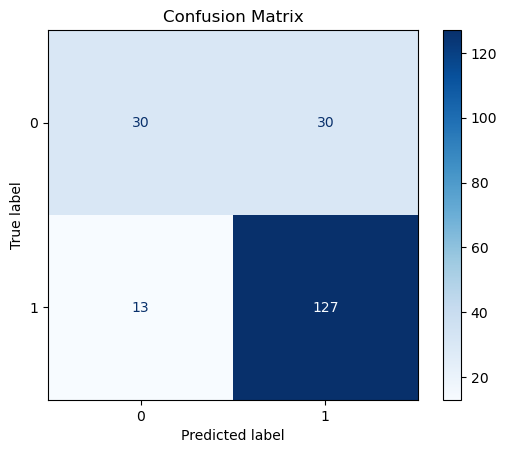

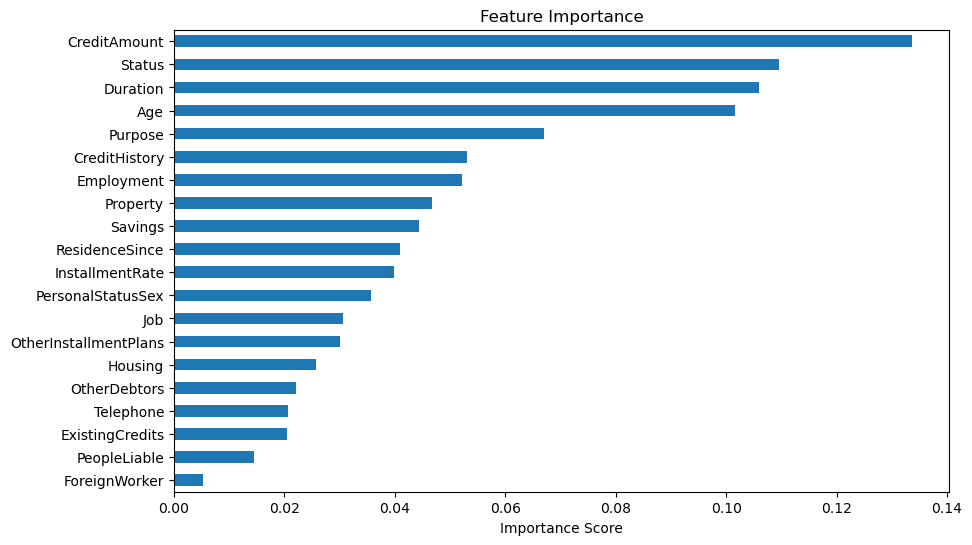

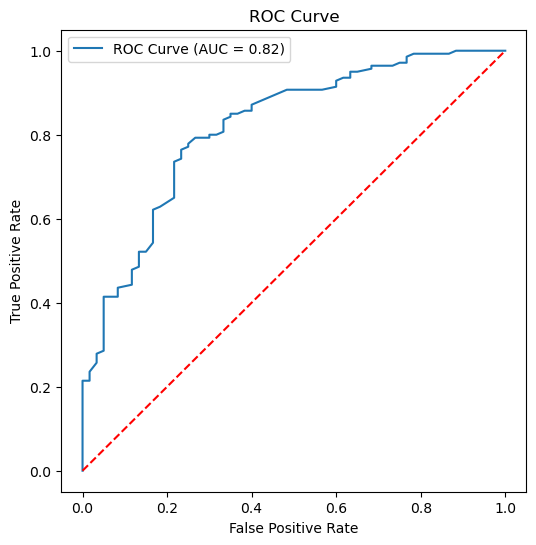

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load German Credit Dataset
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatusSex',
    'OtherDebtors', 'ResidenceSince', 'Property', 'Age',
    'OtherInstallmentPlans', 'Housing', 'ExistingCredits',
    'Job', 'PeopleLiable', 'Telephone', 'ForeignWorker', 'Class'
]

df = pd.read_csv("german.data", sep=r"\s+", header=None, names=columns)

print("First 5 Rows:")
print(df.head())

# Encode categorical columns
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label_encoder.fit_transform(df[col])

# Target Variable
X = df.drop("Class", axis=1)
y = df["Class"]

# Convert target
# Original: 1 = Good, 2 = Bad
# Convert to: Good=1, Bad=0
y = y.map({1:1, 2:0})

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# Evaluation
print("\n========== RESULTS ==========")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

First 5 Rows:
  Status  Duration CreditHistory Purpose  CreditAmount Savings Employment  \
0    A11         6           A34     A43          1169     A65        A75   
1    A12        48           A32     A43          5951     A61        A73   
2    A14        12           A34     A46          2096     A61        A74   
3    A11        42           A32     A42          7882     A61        A74   
4    A11        24           A33     A40          4870     A61        A73   

   InstallmentRate PersonalStatusSex OtherDebtors  ...  Property Age  \
0                4               A93         A101  ...      A121  67   
1                2               A92         A101  ...      A121  22   
2                2               A93         A101  ...      A121  49   
3                2               A93         A103  ...      A122  45   
4                3               A93         A101  ...      A124  53   

   OtherInstallmentPlans Housing ExistingCredits   Job PeopleLiable  \
0                  

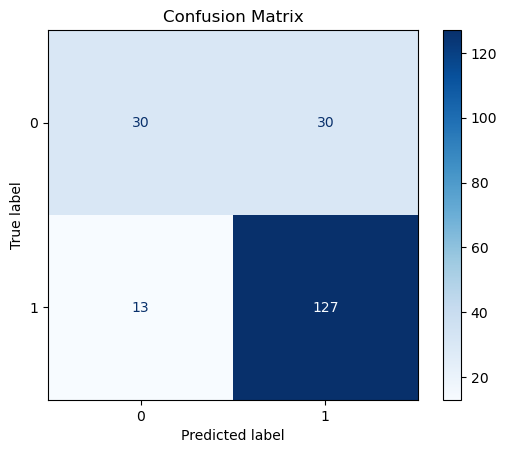

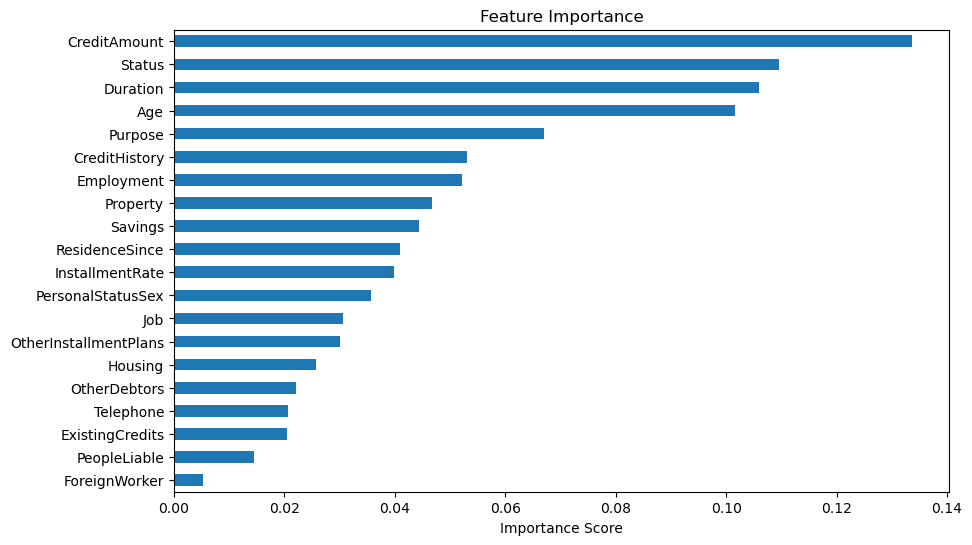

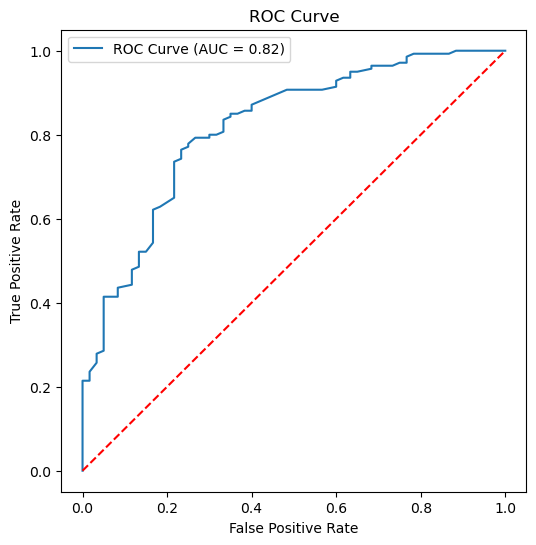

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load German Credit Dataset
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatusSex',
    'OtherDebtors', 'ResidenceSince', 'Property', 'Age',
    'OtherInstallmentPlans', 'Housing', 'ExistingCredits',
    'Job', 'PeopleLiable', 'Telephone', 'ForeignWorker', 'Class'
]

df = pd.read_csv("german.data", sep=r"\s+", header=None, names=columns)

print("First 5 Rows:")
print(df.head())

# Encode categorical columns
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label_encoder.fit_transform(df[col])

# Target Variable
X = df.drop("Class", axis=1)
y = df["Class"]

# Convert target
# Original: 1 = Good, 2 = Bad
# Convert to: Good=1, Bad=0
y = y.map({1:1, 2:0})

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# Evaluation
print("\n========== RESULTS ==========")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()